In [1]:
import torch
from pathlib import Path
from itertools import product

from scripts.material_aware_training import material_aware_training
from scripts.config import PathConfig, MaterialAwareTrainingConfig
from flare.dataset import DatasetLoader
from flare.metrics import metrics
from scripts.flare_inference import build_flare_pipeline, run_inference, visualize_image_batch, visualize_image_buffers
from scripts.util import save_img

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


/home/jsickert/miniconda3/envs/flare/lib/python3.9/site-packages/torch/utils/cpp_extension.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging  # type: ignore[attr-defined]


In [2]:
base_path_config = PathConfig(
    _working_dir="/home/jsickert/adl4cv",
    input_dir="DATA/001",
    train_dir=["MVI_1814", "MVI_1810"],
    eval_dir= ["MVI_1812"],
    output_dir="rgbx_grid_experiment",
    flame_path="/home/jsickert/adl4cv/adl4cv_ws25-26_Relightable-Avatars/flare/flame/FLAME2020/generic_model.pkl",
    diffusion_dir=Path("/home/jsickert/adl4cv/flare_diffusion_channels/rgbx/001"),
    run_name=None
)

In [3]:
dataset_train = DatasetLoader(base_path_config, train_dir=base_path_config.train_dir, sample_ratio=1, pre_load=True)
dataset_val = DatasetLoader(base_path_config, train_dir=base_path_config.eval_dir, sample_ratio=1, pre_load=False)

dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=2, collate_fn=dataset_train.collate, shuffle=True, drop_last=True)
dataloader_val = torch.utils.data.DataLoader(dataset_val, batch_size=4, collate_fn=dataset_val.collate, shuffle=True, drop_last=True)

loaded 2903 views


In [13]:
def evaluate(path_config: PathConfig, dataloader_val, output_dir, run_name):
    mesh, FLAMEServer, deformer_net, shader, renderer, channels_gbuffer, lgt = build_flare_pipeline(
        dataset_val=dataset_val,
        flame_path=path_config.flame_path,
        mesh_path=path_config.working_dir / output_dir / run_name / "stage_2/meshes/mesh_latest.obj",
        deformer_path=path_config.working_dir / output_dir / run_name / "stage_2/network_weights/deformer_latest.pt",
        shader_path=path_config.working_dir / output_dir / run_name / "stage_2/network_weights/shader_latest.pt",
        train_dir=path_config.train_dir,
    )

    for views in dataloader_val:
        rgb_pred, gbuffers, cbuffers = run_inference(views, mesh, FLAMEServer, deformer_net, shader, renderer, channels_gbuffer, lgt)
        rgb_pred = rgb_pred * gbuffers["mask"]
        rgb_pred = rgb_pred.permute(0, 3, 1, 2)

        for i in range(rgb_pred.shape[0]):
            id = int(views["frame_name"][i])
            mask = gbuffers["mask"][i].cpu()
            mask = mask.permute(2, 0, 1)
            rgba_pred = torch.cat([rgb_pred[i].cpu(), mask], dim=0)

            images_save_path = path_config.image_eval_save_path("rgb")
            save_img(rgba_pred, images_save_path / f"{id:05d}.png")

    mae, lpips, ssim, psnr = metrics.run(
        output_dir=path_config.working_dir / output_dir / run_name / "images_evaluation",
        gt_dir=path_config.working_dir / path_config.input_dir,
        subfolders=path_config.eval_dir
    )

    return mae, lpips, ssim, psnr

In [5]:
id_to_config_mapping = {
    
}

In [7]:
for id, (albedo_weight, roughness_weight, normaml_weight) in enumerate(product([0.0, 0.01, 0.1], [0.0, 0.01, 0.1], [0.0, 0.01, 0.1])):
    print(albedo_weight, roughness_weight, normaml_weight)

    training_config1 = MaterialAwareTrainingConfig.default_stage_1_config(batch_size=2, ghostbone=True)
    training_config2 = MaterialAwareTrainingConfig.default_stage_2_config(batch_size=2, ghostbone=True)

    training_config1.weight_diffusion_albedo_regularization = albedo_weight
    training_config1.weight_diffusion_roughness_regularization = roughness_weight
    training_config1.weight_diffusion_normal_regularization = normaml_weight
    training_config2.weight_diffusion_albedo_regularization = albedo_weight
    training_config2.weight_diffusion_roughness_regularization = roughness_weight
    training_config2.weight_diffusion_normal_regularization = normaml_weight

    base_path_config.run_name = f"{id:03d}"

    id_to_config_mapping[id] = (albedo_weight, roughness_weight, normaml_weight)

    if (base_path_config.working_dir / "rgbx_grid_experiment" / f"{id:03d}" / "stage_2/network_weights/shader_latest.pt").exists():
        print("skipping ", id)
        continue

    material_aware_training(
        path_config=base_path_config,
        args1=training_config1,
        args2=training_config2,
        dataset_train=dataset_train,
        dataloader_train=dataloader_train,
    )


0.0 0.0 0.0
skipping  0
0.0 0.0 0.01
skipping  1
0.0 0.0 0.1
skipping  2
0.0 0.01 0.0
skipping  3
0.0 0.01 0.01
skipping  4
0.0 0.01 0.1
skipping  5
0.0 0.1 0.0
skipping  6
0.0 0.1 0.01
skipping  7
0.0 0.1 0.1
skipping  8
0.01 0.0 0.0
skipping  9
0.01 0.0 0.01
skipping  10
0.01 0.0 0.1
creating the FLAME Decoder
Rasterizing: ['mask', 'position', 'normal', 'canonical_position']
Training Deformer
STAGE 1: Using positional encoding (NeRF) for intrinsic materials
{'material_mlp_ch': 5, 'light_mlp_ch': 3, 'material_mlp_dims': [128, 128, 128, 128], 'light_mlp_dims': [64, 64]}
{'mask': 2.0, 'normal': 0.1, 'laplacian': 60.0, 'shading': 1.0, 'perceptual_loss': 0.1, 'albedo_regularization': 0.01, 'roughness_regularization': 0.01, 'white_light_regularization': 0.01, 'fresnel_coeff': 0.01, 'diffusion_normal': 0.1, 'diffusion_albedo': 0.01, 'diffusion_roughness': 0.0, 'diffusion_irradiance': 0.0, 'flame_regularization': 1.0}
Batch Size: 2


Epoch 0, Iter 1:   0%|          | 0/2 [00:00<?, ?it/s]Using /home/jsickert/.cache/torch_extensions/py39_cu116 as PyTorch extensions root...
Detected CUDA files, patching ldflags
Emitting ninja build file /home/jsickert/.cache/torch_extensions/py39_cu116/renderutils_plugin/build.ninja...
Building extension module renderutils_plugin...
Allowing ninja to set a default number of workers... (overridable by setting the environment variable MAX_JOBS=N)


ninja: no work to do.


Loading extension module renderutils_plugin...
Epoch 0, Iter 100:   0%|          | 0/2 [00:41<?, ?it/s, loss=0.544]

Decaying flame regularization


...

Upsampling at iteration: 500
Vertices: (17696, 3)
Faces: (35352, 3)
laplacian weight 240.0
normal consistency weight 0.4
lr vertices 0.00075


Epoch 1, Iter 2902: 100%|██████████| 2/2 [14:18<00:00, 429.17s/it, loss=0.097] 


TIME TAKEN (mins): 14
loading mesh from: /home/jsickert/adl4cv/rgbx_grid_experiment/026/stage_1/meshes/mesh_latest.obj
Rasterizing: ['mask', 'position', 'normal', 'canonical_position']
Loading deformer network trained in the previous stage
STAGE 2: Using hashgrid (tinycudann) for intrinsic materials
{'material_mlp_ch': 5, 'light_mlp_ch': 3, 'material_mlp_dims': [64, 64], 'light_mlp_dims': [64, 64]}
{'mask': 2.0, 'normal': 0.1, 'laplacian': 60.0, 'shading': 1.0, 'perceptual_loss': 0.1, 'albedo_regularization': 0.01, 'roughness_regularization': 0.01, 'white_light_regularization': 0.01, 'fresnel_coeff': 0.01, 'diffusion_normal': 0.1, 'diffusion_albedo': 0.1, 'diffusion_roughness': 0.1, 'diffusion_irradiance': 0.0, 'flame_regularization': 0.0}
Batch Size: 2


Epoch 0, Iter 1451: 100%|██████████| 1/1 [06:53<00:00, 413.52s/it, loss=0.12]

TIME TAKEN (mins): 6


In [9]:
id_to_metrics_mapping = {
    
}

In [14]:
for id, config in id_to_config_mapping.items():
    base_path_config.run_name = f"{id:03d}"

    mae, lpips, ssim, psnr = evaluate(
        path_config=base_path_config,
        dataloader_val=dataloader_val,
        output_dir="rgbx_grid_experiment",
        run_name=f"{id:03d}",
    )

    id_to_metrics_mapping[id] = (mae, lpips, ssim, psnr)  

creating the FLAME Decoder
STAGE 2: Using hashgrid (tinycudann) for intrinsic materials
{'material_mlp_ch': 5, 'light_mlp_ch': 3, 'material_mlp_dims': [64, 64], 'light_mlp_dims': [64, 64]}
rgb
image index start from:  1
['1791', '1473', '499', '543', '115', '1686', '710', '167', '310', '1482', '1467', '882', '1364', '904', '735', '885', '1560', '211', '1714', '1172', '156', '89', '1134', '588', '104', '1080', '894', '1752', '1269', '1083', '1630', '1672', '675', '1487', '1405', '739', '294', '627', '733', '1014', '23', '1521', '434', '317', '1579', '1812', '1675', '1444', '173', '1137', '1709', '1626', '707', '10', '624', '1210', '446', '1085', '1428', '1734', '886', '1494', '1347', '1737', '1776', '1251', '1326', '1437', '1522', '1407', '1304', '1638', '231', '965', '1076', '1021', '19', '487', '21', '1561', '972', '838', '1742', '1383', '616', '509', '309', '1376', '683', '681', '137', '797', '1271', '1392', '336', '577', '836', '1597', '768', '1352', '117', '1550', '523', '464', '60

  0%|          | 0/1820 [00:00<?, ?it/s]

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


[ WARN:0@37735.595] global loadsave.cpp:1063 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.
/home/jsickert/miniconda3/envs/flare/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jsickert/miniconda3/envs/flare/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/jsickert/miniconda3/envs/flare/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/jsickert/minico

Loading model from: /home/jsickert/miniconda3/envs/flare/lib/python3.9/site-packages/lpips/weights/v0.1/alex.pth
nan	nan	nan	nan	nan


...

0.027297457802342252	0.10373491001781077	0.8536503292992711	23.942434003353117	nan


 99%|█████████▉| 1803/1820 [03:02<00:01, 10.43it/s]

0.02725929088373151	0.10360802481571833	0.8537382847401831	23.95230340745714	nan


100%|██████████| 1820/1820 [03:04<00:00,  9.88it/s]

Written result to  /home/jsickert/adl4cv/rgbx_grid_experiment/026/images_evaluation/results_no_cloth_rgb.npz
0.027250324922439815	0.10358057888327064	0.8537483819893428	23.955577300145077


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = []

for run_id in id_to_config_mapping:
    data.append(list(id_to_config_mapping[run_id]) + list(id_to_metrics_mapping[run_id]))

config_cols = ["albedo", "roughness", "normal"]
metric_cols = ["mae", "lpips", "ssim", "psnr"]
df = pd.DataFrame(data, columns=config_cols + metric_cols, index=id_to_config_mapping.keys())

In [ ]:
df.to_pickle("rgbx_grid_search_results.pkl")

In [42]:
df.to_csv("rgbx_grid_search_results.csv")

 albedo  roughness  normal      mae    lpips     ssim      psnr                 config
   0.00       0.00    0.00 0.026202 0.100554 0.853882 24.108796    n=0.0, a=0.0, r=0.0
   0.00       0.01    0.00 0.025683 0.100330 0.855453 24.198113   n=0.0, a=0.0, r=0.01
   0.00       0.10    0.00 0.025653 0.097913 0.858561 24.291581    n=0.0, a=0.0, r=0.1
   0.01       0.00    0.00 0.026241 0.101721 0.854344 24.073052   n=0.0, a=0.01, r=0.0
   0.01       0.01    0.00 0.025791 0.101232 0.856422 24.217861  n=0.0, a=0.01, r=0.01
   0.01       0.10    0.00 0.026012 0.100785 0.855383 24.065011   n=0.0, a=0.01, r=0.1
   0.10       0.00    0.00 0.026738 0.101959 0.855650 23.977933    n=0.0, a=0.1, r=0.0
   0.10       0.01    0.00 0.027322 0.103614 0.852664 23.861135   n=0.0, a=0.1, r=0.01
   0.10       0.10    0.00 0.026659 0.100622 0.855640 23.998050    n=0.0, a=0.1, r=0.1
   0.00       0.00    0.01 0.025709 0.099224 0.856013 24.172846   n=0.01, a=0.0, r=0.0
   0.00       0.01    0.01 0.025769 0.09881

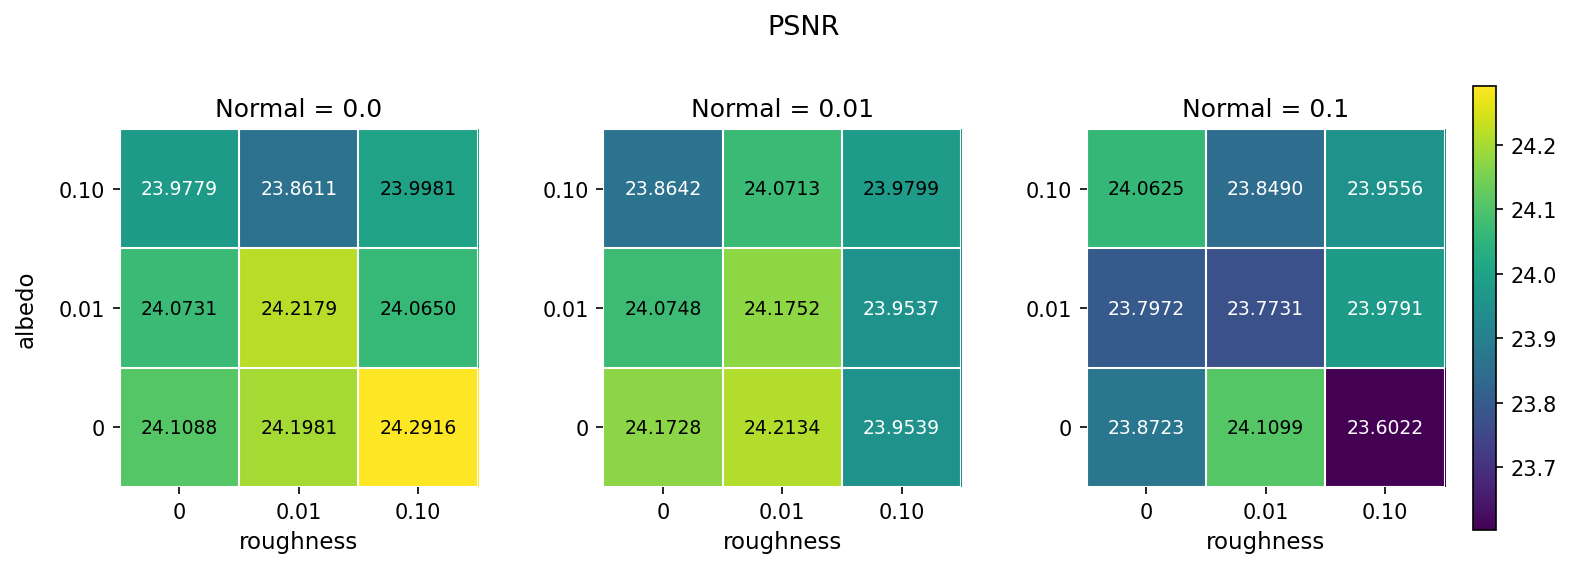

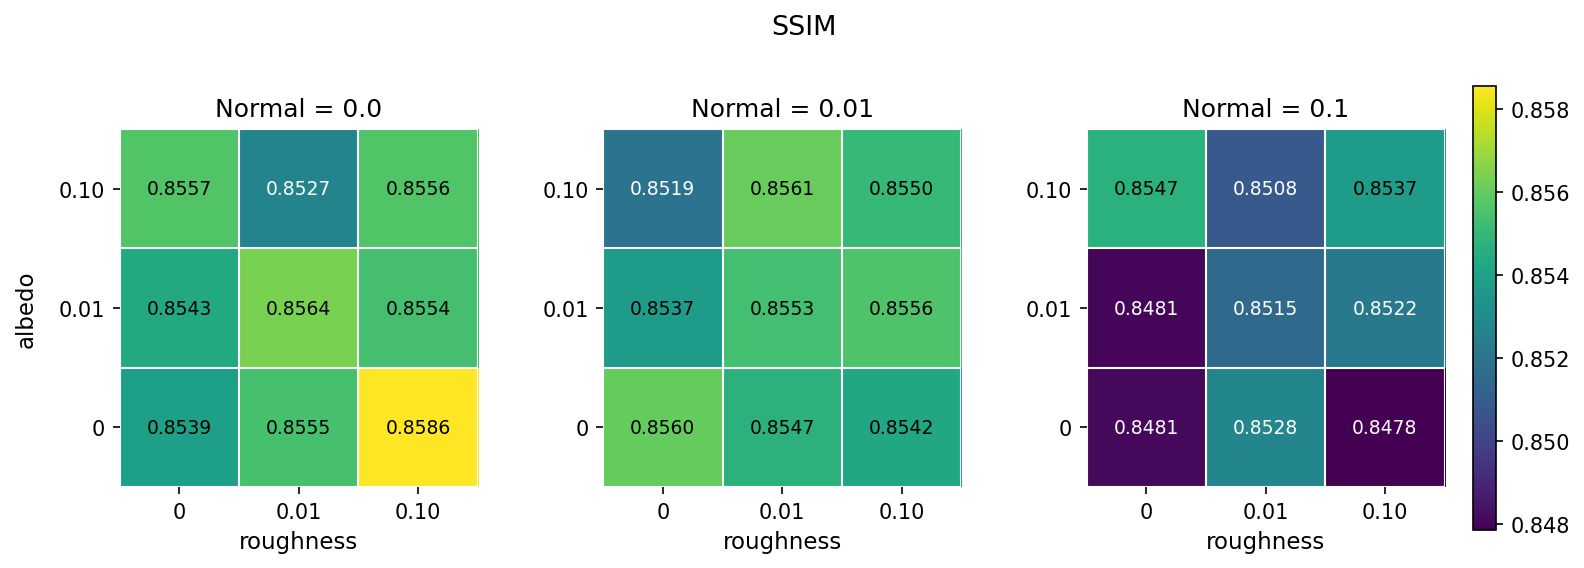

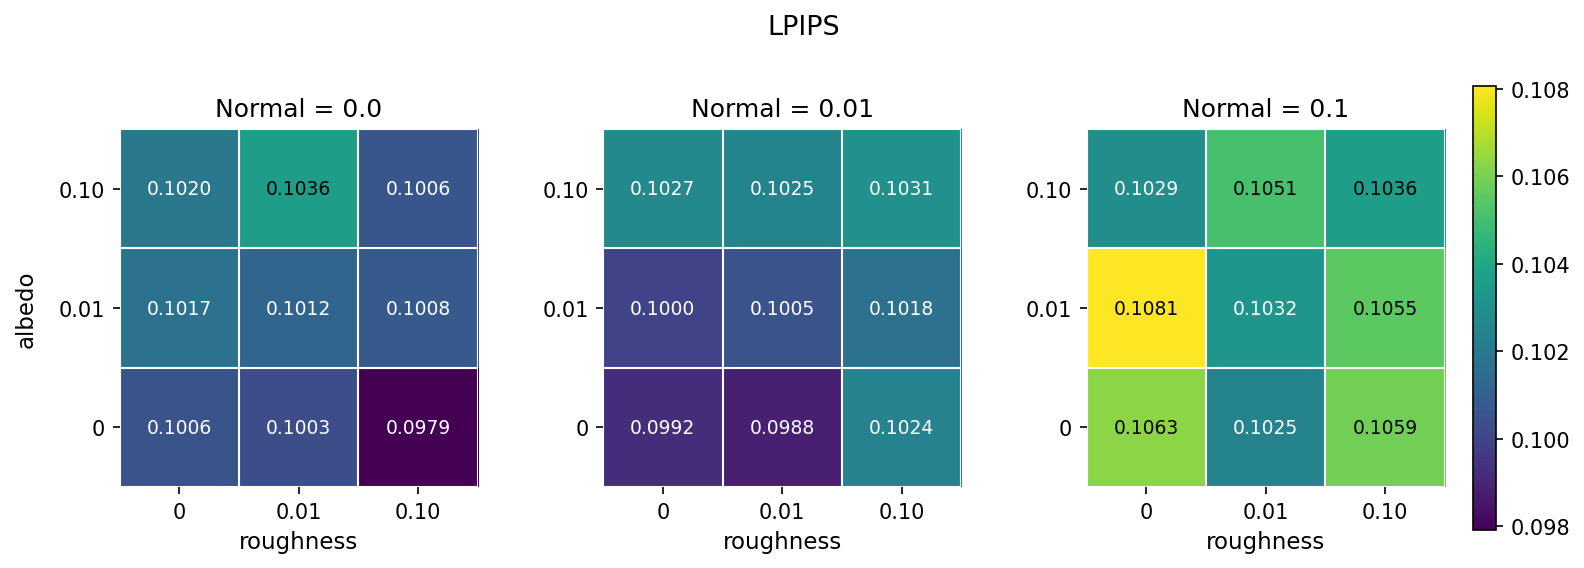

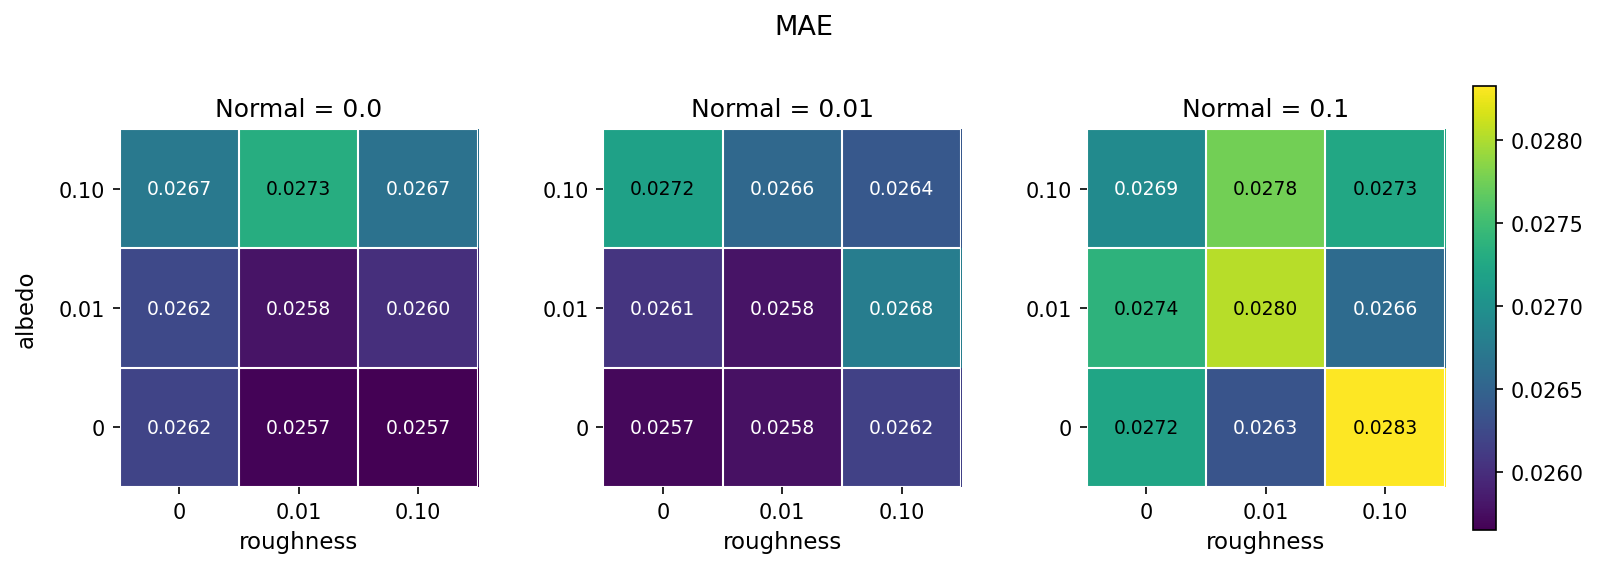

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

df_input = df
vals = [0.0, 0.01, 0.1]
full = pd.MultiIndex.from_product([vals, vals, vals], names=['albedo','roughness','normal']).to_frame(index=False)

# Merge provided results into the full grid; missing combos become NaN.
# If duplicates existed in the original data, keep last occurrence (pandas does that by default on merge if we drop duplicates)
# But we'll detect duplicates first for transparency.
duplicates = df_input[df_input.duplicated(subset=['normal','albedo','roughness'], keep=False)]
dup_warning = None
if not duplicates.empty:
    dup_warning = "Warning: duplicate rows found for the same configuration. I'll keep the last occurrence for each duplicate key."
    # Keep last occurrence:
    df_input = df_input.drop_duplicates(subset=['normal','albedo','roughness'], keep='last')

df = full.merge(df_input, on=['normal','albedo','roughness'], how='left').sort_values(['normal','albedo','roughness'])
df = df.reset_index(drop=True)

# For display, create a string label for each config
df['config'] = df.apply(lambda r: f"n={r['normal']}, a={r['albedo']}, r={r['roughness']}", axis=1)

print(df.to_string(index=False))

# Helper to save and return filenames
saved_files = []

# Plotting heatmaps: one figure per (metric, fixed normal) pair — this avoids subplots and obeys the "one chart per figure" rule.
metrics = {
    'psnr': {'label': 'PSNR', 'higher_better': True},
    'ssim': {'label': 'SSIM', 'higher_better': True},
    'lpips': {'label': 'LPIPS', 'higher_better': False},
    'mae': {'label': 'MAE', 'higher_better': False},
}

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.dpi': 150,
})

def fmt_tick(x):
    if float(x).is_integer():
        return f"{int(x)}"
    return f"{x:.2f}"

for metric, meta in metrics.items():
    # collect pivots for each normal value
    pivots = []
    for n in vals:
        pivot = df[df['normal'] == n].pivot(index='albedo', columns='roughness', values=metric)
        pivot = pivot.reindex(index=vals, columns=vals)  # ensures order 0.0,0.01,0.1
        pivots.append(pivot)

    # common vmin/vmax (ignore NaNs)
    stacked = np.array([p.values for p in pivots], dtype=float)
    vmin = np.nanmin(stacked)
    vmax = np.nanmax(stacked)
    if np.isfinite(vmin) and np.isfinite(vmax) and (vmax - vmin) < 1e-6:
        pad = abs(vmin) * 0.01 + 1e-3
        vmin -= pad
        vmax += pad

    # create figure with 1x3 horizontal panels
    n_panels = len(vals)
    fig, axes = plt.subplots(1, n_panels, figsize=(12, 4), constrained_layout=False)
    if n_panels == 1:
        axes = [axes]

    # use modern colormap (avoid deprecated call)
    cmap = mpl.colormaps.get_cmap('viridis').copy()
    cmap.set_bad(color='lightgray')  # NaN cells in light gray

    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    for ax, pivot, n in zip(axes, pivots, vals):
        arr = pivot.values.astype(float)
        masked = np.ma.masked_invalid(arr)
        im = ax.imshow(masked, origin='lower', interpolation='nearest',
               aspect='equal', cmap=cmap, norm=norm)
        # im = ax.imshow(masked, vmin=vmin, vmax=vmax, origin='lower',
        #                interpolation='nearest', aspect='equal', cmap=cmap, norm=norm)

        # ticks & labels
        ax.set_xticks(np.arange(len(pivot.columns)))
        ax.set_yticks(np.arange(len(pivot.index)))
        ax.set_xticklabels([fmt_tick(x) for x in pivot.columns])
        ax.set_yticklabels([fmt_tick(x) for x in pivot.index])
        ax.set_xlabel("roughness")
        ax.set_title(f"Normal = {n}")

        # only the leftmost axes gets the ylabel (visible on slides)
        if ax is axes[0]:
            ax.set_ylabel("albedo", labelpad=10)

        # crisp white grid lines between cells
        ax.set_xticks(np.arange(-.5, len(pivot.columns), 1), minor=True)
        ax.set_yticks(np.arange(-.5, len(pivot.index), 1), minor=True)
        ax.grid(which='minor', color='white', linestyle='-', linewidth=1)
        ax.tick_params(which='minor', length=0)
        for spine in ax.spines.values():
            spine.set_visible(False)

        # annotate cells with contrast-aware text color using luminance of the cmap color
        for (i, j), val in np.ndenumerate(arr):
            if np.isnan(val):
                txt = "—"
                color = "black"
            else:
                txt = f"{val:.4f}"
                # normalized value for colormap lookup
                if np.isfinite(vmin) and np.isfinite(vmax) and vmax > vmin:
                    norm_val = (val - vmin) / (vmax - vmin)
                    norm_val = np.clip(norm_val, 0.0, 1.0)
                else:
                    norm_val = 0.5
                rgba = cmap(norm_val)
                # compute luminance (rec. 709)
                r, g, b = rgba[0], rgba[1], rgba[2]
                luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
                # white text on dark cells (low luminance), black on light cells
                color = 'white' if luminance < 0.5 else 'black'
            ax.text(j, i, txt, ha='center', va='center', fontsize=9, color=color)

    # place a single shared colorbar to the right
    # use a ScalarMappable to attach the same norm & cmap
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])  # required for colorbar
    # adjust space for colorbar and suptitle manually to avoid tight_layout warnings
    fig.subplots_adjust(left=0.12, right=0.92, top=0.86, bottom=0.12, wspace=0.35)
    cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation='vertical', fraction=0.06, pad=0.02)
    fig.suptitle(f"{meta['label']}", fontsize=13)
    plt.show(fig)